--> Text cleaning completed.

--> Models training started...

========== MODELS KI PERFORMANCE ==========
         Model Name  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.985714   0.985714 0.985714  0.985714
          SVM Model  0.978571   0.978872 0.978571  0.978058
      Decision Tree  0.941429   0.944003 0.941429  0.942382
      Random Forest  0.935714   0.941138 0.935714  0.928035

[+] Best model: Logistic Regression


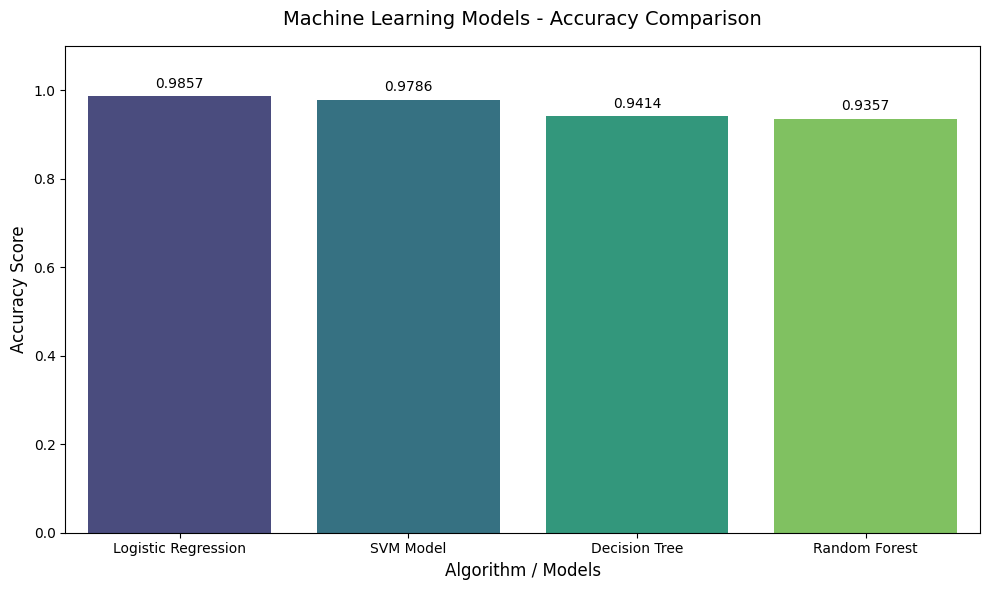


[SUCCESS] Best Model, Scaler, Vectorizer and Encoder are saved.


In [4]:
import pandas as pd
import numpy as np
import nltk
import re
import string
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. NLP Tools Download Karna
# ==========================================
# Yeh sirf zaroori text processing tools download karega
nltk.download(['punkt', 'stopwords', 'wordnet', 'punkt_tab'], quiet=True)

# ==========================================
# 2. Dataset Load Karna
# ==========================================
dataset_name = 'clean_dataset.csv'  # Naye client ka dataset
df = pd.read_csv(dataset_name)

# Column names se aage-peeche ki extra spaces hatana
df.columns = df.columns.str.strip()

# ==========================================
# 3. Text (NLP) Ki Safai Aur Combination
# ==========================================
eng_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # Sab letters ko chota (lowercase) karna
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text) # Punctuation marks hatana
    tokens = word_tokenize(text) # Jumlay ko chote words mein todna
    
    # Faltu words (stopwords) nikalna aur words ko unki asli halat (lemma) mein lana
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in eng_stopwords]
    return " ".join(cleaned)

# Naye dataset mein 2 text columns hain, dono ko mila kar ek strong text feature banate hain
df['Combined_Text'] = df['Teacher_Remarks'].astype(str) + " " + df['Extracurricular_Feedback'].astype(str)

# Combine kiye hue text par safai wala function apply karna
df['Cleaned_Text'] = df['Combined_Text'].apply(clean_text)
print("--> Text cleaning completed.")

# ==========================================
# 4. Tabular Data Set Karna
# ==========================================
# Agar koi value missing hai, toh usko sab se common value (mode) se fill karna
for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0])

encoder = LabelEncoder()
target_encoder = LabelEncoder() # Target ke liye alag encoder taake baad mein inverse_transform asaan ho

# Naye dataset ke categorical columns
cat_columns = ['Gender', 'Course', 'Section', 'Study_Habits', 'Disciplinary_Record', 'Internship_Status', 'Project_Title']

# Text wale categorical columns ko numbers (0, 1, 2) mein badalna
for col in cat_columns:
    if col in df.columns:
        df[col] = encoder.fit_transform(df[col].astype(str))

# Hamara Naya Target 'Student_Grade_Band' hai, isko numbers mein convert karna
df['Target_Grade'] = target_encoder.fit_transform(df['Student_Grade_Band'])

# ==========================================
# 5. Zaroori Features Select Karna
# ==========================================
# WARNING: 'Final_Obtained_Score' ko nikalna bohot zaroori hai warna model cheat karega!
cols_to_drop = [
    'Student_ID', 'Registration_No', 'Student_Grade_Band', 'Target_Grade', 
    'Final_Obtained_Score', 'Teacher_Remarks', 'Extracurricular_Feedback', 
    'Combined_Text', 'Cleaned_Text'
]

# Sirf numeric (numbers wale) columns ko input features (X) banana
X_numbers = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
X_numbers = X_numbers.select_dtypes(include=[np.number])

# Text column aur Target column ko alag karna
X_text = df['Cleaned_Text']
y = df['Target_Grade']

# Data ko Train aur Test hisson mein baantna (80% Train, 20% Test)
X_train_num, X_test_num, X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_numbers, X_text, y, test_size=0.2, random_state=42
)

# ==========================================
# 6. Scaling aur Vectorization
# ==========================================
# Numbers ko ek hi scale par lana taake model sahi se seekh sake
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Text ko mathematical numbers (TF-IDF) mein badalna (Features thore barha diye hain better NLP ke liye)
vectorizer = TfidfVectorizer(max_features=150) 
X_train_tfidf = vectorizer.fit_transform(X_train_txt).toarray()
X_test_tfidf = vectorizer.transform(X_test_txt).toarray()

# Numbers aur Text wale features ko aapas mein mila dena
X_train_final = np.hstack((X_train_num_scaled, X_train_tfidf))
X_test_final = np.hstack((X_test_num_scaled, X_test_tfidf))

# ==========================================
# 7. Models Ki Training Aur Testing
# ==========================================
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM Model": SVC(probability=True)
}

model_results = []
best_accuracy = 0
best_model = None

print("\n--> Models training started...")

for model_name, model in ml_models.items():
    model.fit(X_train_final, y_train) # Model ko training data par sikhana
    predictions = model.predict(X_test_final) # Test data par test karna

    # Model ki accuracy check karna
    acc = accuracy_score(y_test, predictions)

    model_results.append({
        "Model Name": model_name,
        "Accuracy": acc,
        "Precision": precision_score(y_test, predictions, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, predictions, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, predictions, average='weighted', zero_division=0)
    })

    # Agar current model ki accuracy sab se zyada hai, toh usay save kar lena
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

# Results ko table ki shakal mein print karna
results_df = pd.DataFrame(model_results).sort_values(by='Accuracy', ascending=False)
print("\n========== MODELS KI PERFORMANCE ==========")
print(results_df.to_string(index=False))

print(f"\n[+] Best model: {results_df.iloc[0]['Model Name']}")

# ==========================================
# 8. Graph Banana (Matplotlib & Seaborn)
# ==========================================
plt.figure(figsize=(10, 6))

# Bar chart banana (legend=False hata diya hai)
ax = sns.barplot(x='Model Name', y='Accuracy', data=results_df, hue='Model Name', palette='viridis', dodge=False)

# Legend ko manually hide karna
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Har bar ke upar uski exact accuracy likhna
for p in ax.patches:
    # Baaz dafa hue use karne se empty bars ban jati hain (0 height), unko ignore karne ke liye:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.4f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

plt.title('Machine Learning Models - Accuracy Comparison', fontsize=14, pad=15)
plt.xlabel('Algorithm / Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.1)
plt.tight_layout() # Graph ko screen par fit karne ke liye
plt.show() # Graph ko display karna

# ==========================================
# 9. Best Model Save Karna (Deployment Ke Liye)
# ==========================================
if best_model is not None:
    joblib.dump(best_model, "best_student_model.pkl")
    joblib.dump(scaler, "scaler_obj.pkl")
    joblib.dump(vectorizer, "tfidf_obj.pkl")
    joblib.dump(target_encoder, "target_encoder.pkl") # Target label inverse transform ke liye zaroori hai
    print("\n[SUCCESS] Best Model, Scaler, Vectorizer and Encoder are saved.")
else:
    print("\n[ERROR] Model couldn't save.")